# Graphs

/tmp/ipykernel_4722/1031127097.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Variable', y='Value', data=df_melt,


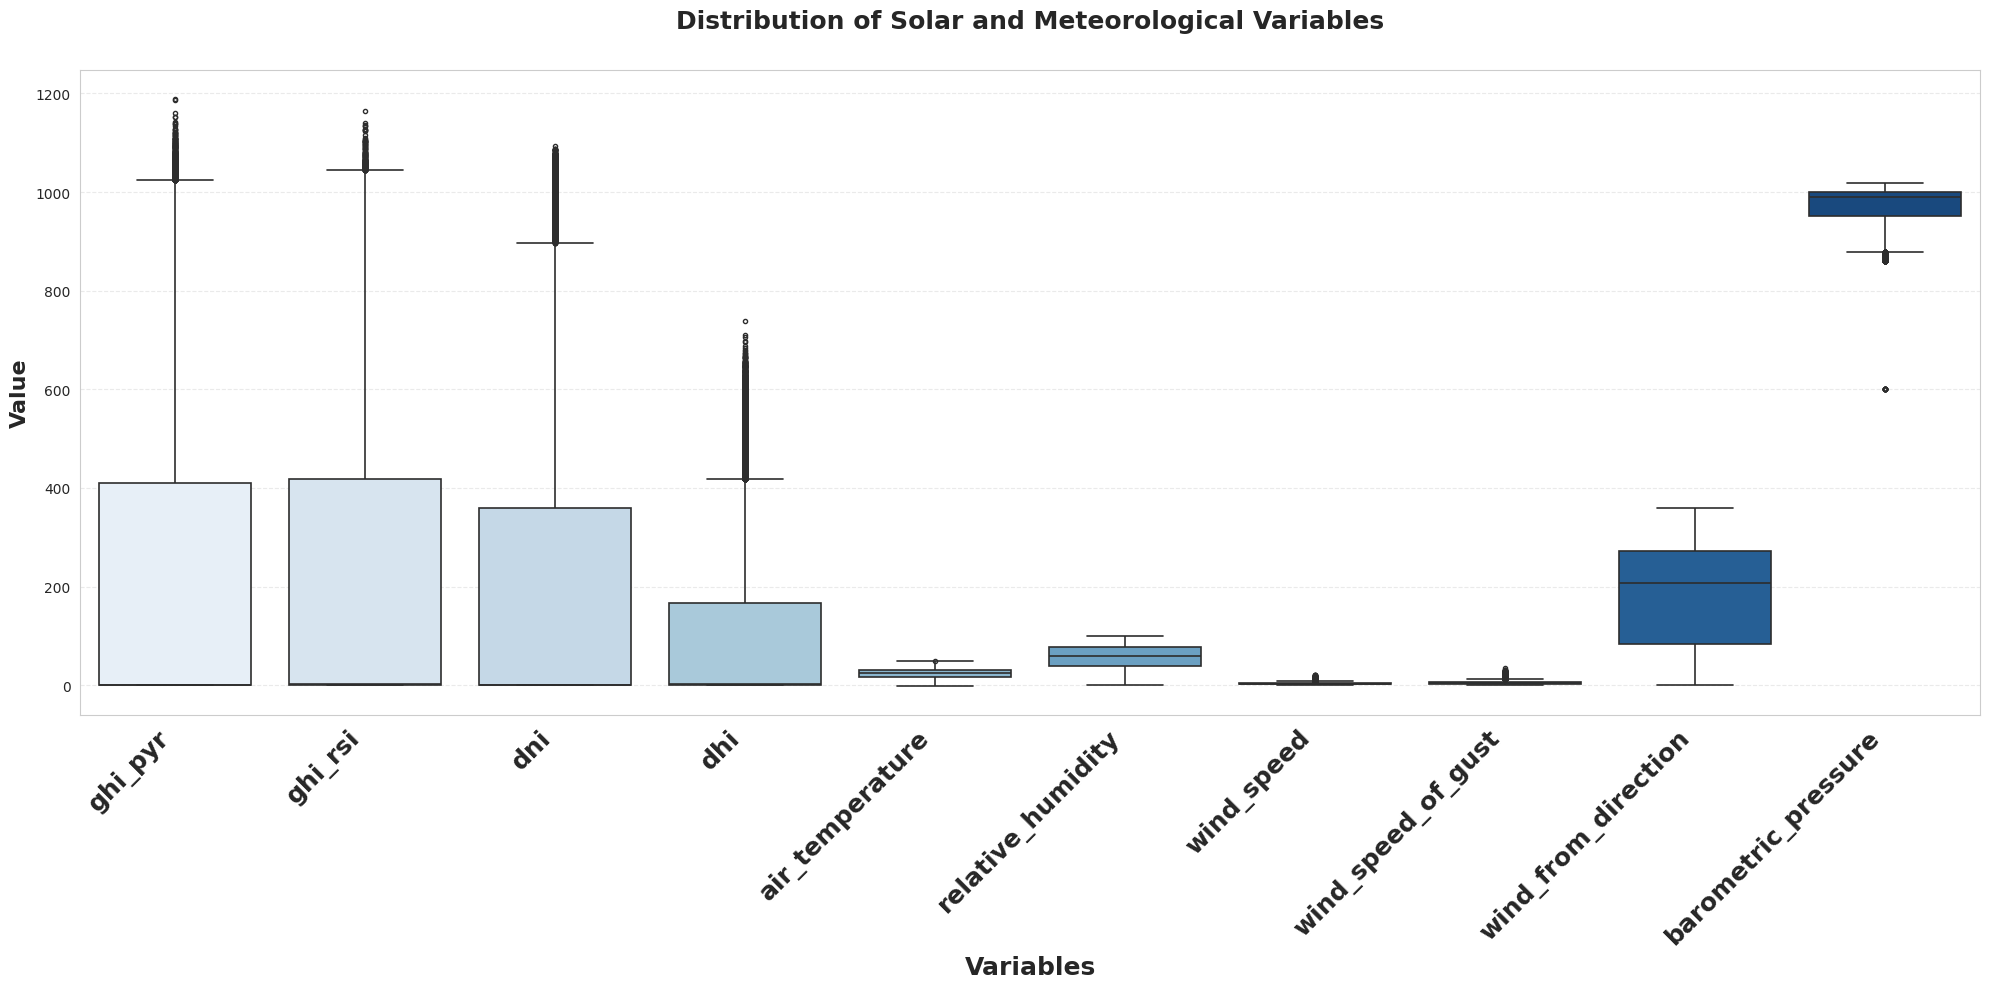

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ====================== DATA LOAD ======================
df = pd.read_csv('/content/pakistan_solar_measurements_all_locations_merged.csv',
                 low_memory=False)

# ====================== NUMERIC COLUMNS SELECT ======================
numeric_cols = [
    'ghi_pyr', 'ghi_rsi', 'dni', 'dhi',
    'air_temperature', 'relative_humidity',
    'wind_speed', 'wind_speed_of_gust',
    'wind_from_direction', 'barometric_pressure',
    'clear_sky_index', 'hour_sin', 'hour_cos',
    'day_sin', 'day_cos'
]

available_cols = [col for col in numeric_cols if col in df.columns]

# ====================== BOXPLOT with Colors ======================
plt.figure(figsize=(20, 10))

sns.set_style("whitegrid")

df_melt = pd.melt(df[available_cols], var_name='Variable', value_name='Value')

palette = sns.color_palette("Blues", n_colors=len(available_cols))

ax = sns.boxplot(x='Variable', y='Value', data=df_melt,
                 palette=palette,
                 fliersize=3,
                 linewidth=1.2)

# Box styling
for i, box in enumerate(ax.artists):
    box.set_edgecolor('navy')
    box.set_facecolor(palette[i])
    ax.lines[i*6 + 4].set_color('red')
    ax.lines[i*6 + 4].set_linewidth(2.5)

plt.title('Distribution of Solar and Meteorological Variables',
          fontsize=18, pad=30, fontweight='bold')

plt.ylabel('Value', fontsize=16, fontweight='bold')
plt.xlabel('Variables', fontsize=18, fontweight='bold')

# ←←← X-axis labels  ←←←
plt.xticks(rotation=45,
           ha='right',
           fontsize=18,           # size
           fontweight='bold')     # bold

plt.grid(True, axis='y', alpha=0.4, linestyle='--')

plt.tight_layout()

plt.savefig('boxplot_colored_solar_variables.png', dpi=400, bbox_inches='tight')
plt.show()

In [ ]:
df['time'] = pd.to_datetime(df['time'])

df['season'] = df['time'].dt.month.map(
    lambda x:
    'Winter' if x in [12,1,2] else
    'Spring' if x in [3,4,5] else
    'Summer' if x in [6,7,8] else
    'Autumn'
)

print(df['season'].value_counts())

season
Winter    276310
Spring    265762
Autumn    252631
Summer    198025
Name: count, dtype: int64


/tmp/ipykernel_1388/4257593034.py:5: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/pakistan_solar_measurements_all_locations_merged.csv')


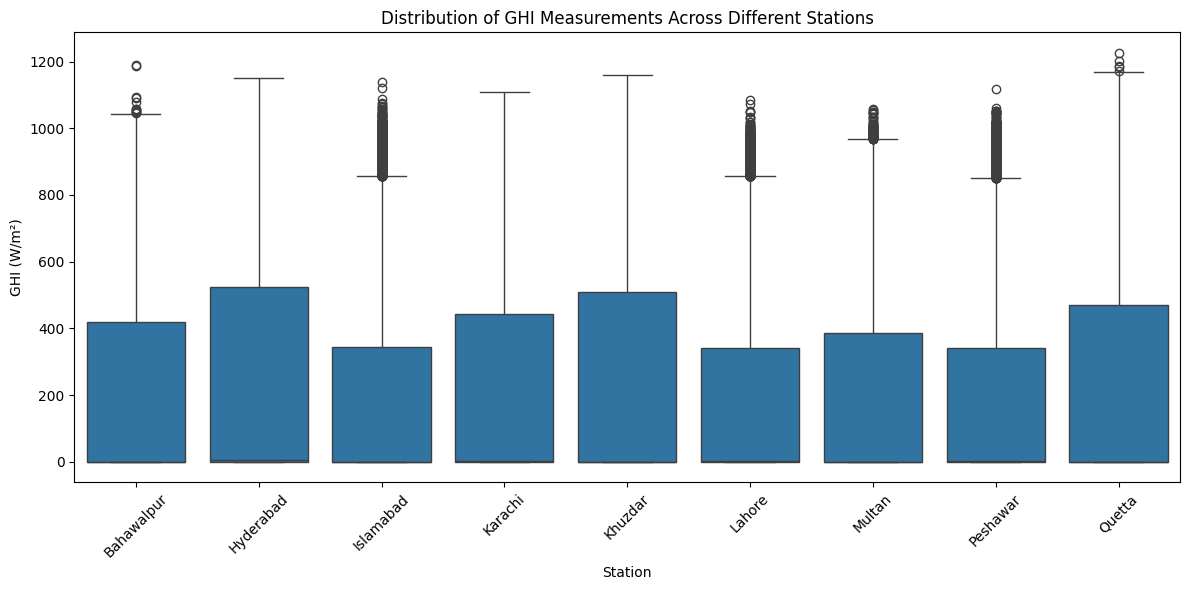

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/pakistan_solar_measurements_all_locations_merged.csv')

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='location',   # replace with your station column
    y='ghi_pyr'         # replace with your GHI column
)

plt.xlabel('Station')
plt.ylabel('GHI (W/m²)')
plt.title('Distribution of GHI Measurements Across Different Stations')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1388/3498438114.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Variable', y='Value', data=df_melt,


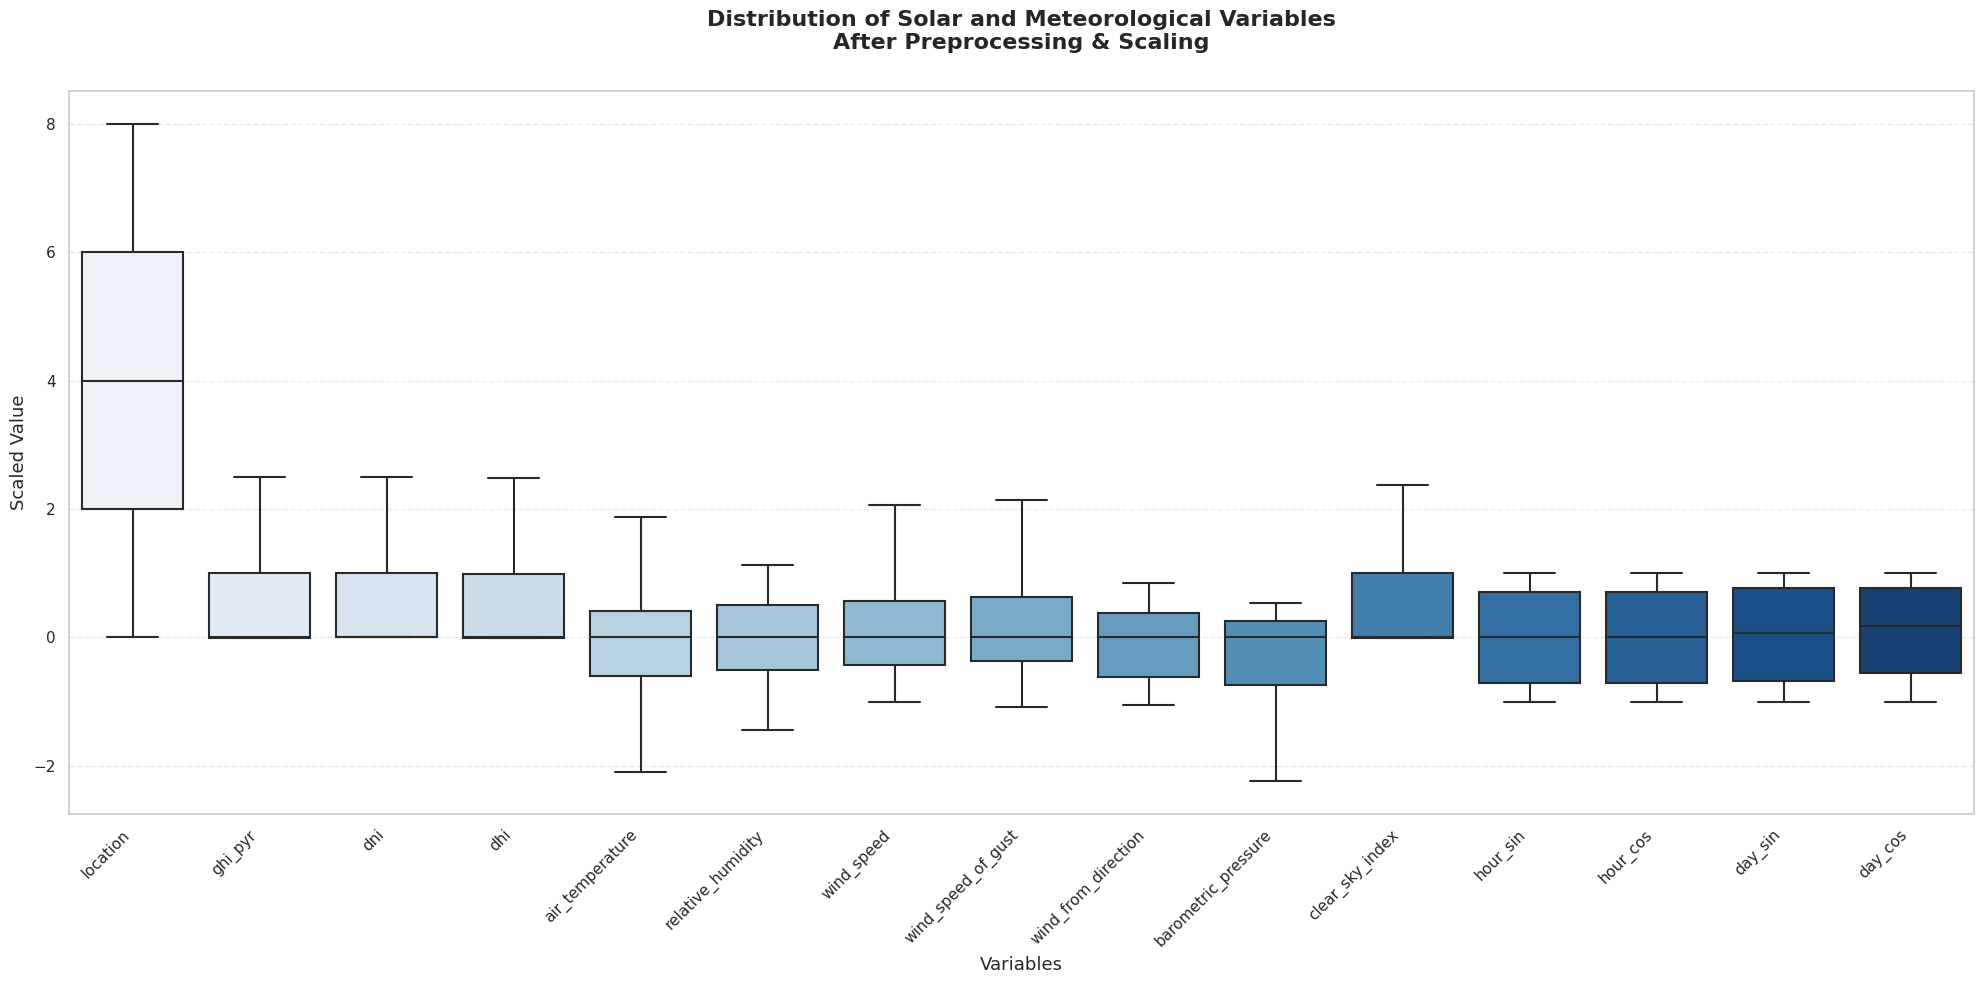

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import RobustScaler, LabelEncoder

# ========================== PREPROCESSING ==========================
df = pd.read_csv("/content/pakistan_solar_measurements_all_locations_merged.csv", low_memory=False)

# Drop unnecessary columns
df = df.drop(columns=['comments', 'sensor_cleaning', 'ghi_rsi'])

# Convert time
df['time'] = pd.to_datetime(df['time'], errors='coerce')

# Fill missing values
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df['location'] = df['location'].fillna(df['location'].mode()[0])

# Encode location
le = LabelEncoder()
df['location'] = le.fit_transform(df['location'])

# Feature Engineering
df['hour'] = df['time'].dt.hour
df['day_of_year'] = df['time'].dt.dayofyear

df['ghi_max_day'] = df.groupby(df['day_of_year'])['ghi_pyr'].transform('max')
df['clear_sky_index'] = df['ghi_pyr'] / df['ghi_max_day']
df.drop(columns=['ghi_max_day'], inplace=True)

df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_year']/366)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_year']/366)
df = df.drop(columns=['hour','day_of_year'])

# Outlier Handling
gust_lower, gust_upper = df['wind_speed_of_gust'].quantile([0.01, 0.99])
pressure_lower, pressure_upper = df['barometric_pressure'].quantile([0.01, 0.99])
df = df[(df['wind_speed_of_gust'] >= gust_lower) & (df['wind_speed_of_gust'] <= gust_upper)]
df = df[(df['barometric_pressure'] >= pressure_lower) & (df['barometric_pressure'] <= pressure_upper)]

numeric_cols = df.select_dtypes(include='number').columns
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
df[numeric_cols] = df[numeric_cols].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR, axis=1)

for col in ['wind_speed_of_gust','barometric_pressure']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower, upper=upper)

# Scaling
scale_cols = ['ghi_pyr','dni','dhi','air_temperature','relative_humidity',
              'wind_speed','wind_speed_of_gust','wind_from_direction',
              'barometric_pressure','clear_sky_index']
scaler = RobustScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# ========================== BLUE BOXPLOT AFTER PREPROCESSING ==========================
plt.figure(figsize=(20, 10))

sns.set_style("whitegrid")

# Final Columns (ghi_rsi removed)
columns_to_plot = [
    'location', 'ghi_pyr',
    'dni', 'dhi', 'air_temperature', 'relative_humidity',
    'wind_speed', 'wind_speed_of_gust', 'wind_from_direction',
    'barometric_pressure', 'clear_sky_index',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos'
]

# Melt the data
df_melt = pd.melt(df[columns_to_plot], var_name='Variable', value_name='Value')

# Blues Palette
palette = sns.color_palette("Blues", n_colors=len(columns_to_plot))

ax = sns.boxplot(x='Variable', y='Value', data=df_melt,
                 palette=palette,
                 fliersize=4,
                 linewidth=1.5)

# Enhancements
for i, box in enumerate(ax.artists):
    box.set_edgecolor('navy')
    box.set_facecolor(palette[i])
    # Median line
    ax.lines[i*6 + 4].set_color('darkred')
    ax.lines[i*6 + 4].set_linewidth(2.8)

plt.title('Distribution of Solar and Meteorological Variables\nAfter Preprocessing & Scaling',
          fontsize=16, pad=30, fontweight='bold')

plt.ylabel('Scaled Value', fontsize=13)
plt.xlabel('Variables', fontsize=13)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.grid(True, axis='y', alpha=0.4, linestyle='--')

plt.tight_layout()

plt.savefig('boxplot_after_preprocessing_blues_final.png', dpi=400, bbox_inches='tight')
plt.show()

/tmp/ipykernel_4722/3996110357.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Variable', y='Value', data=df_melt,


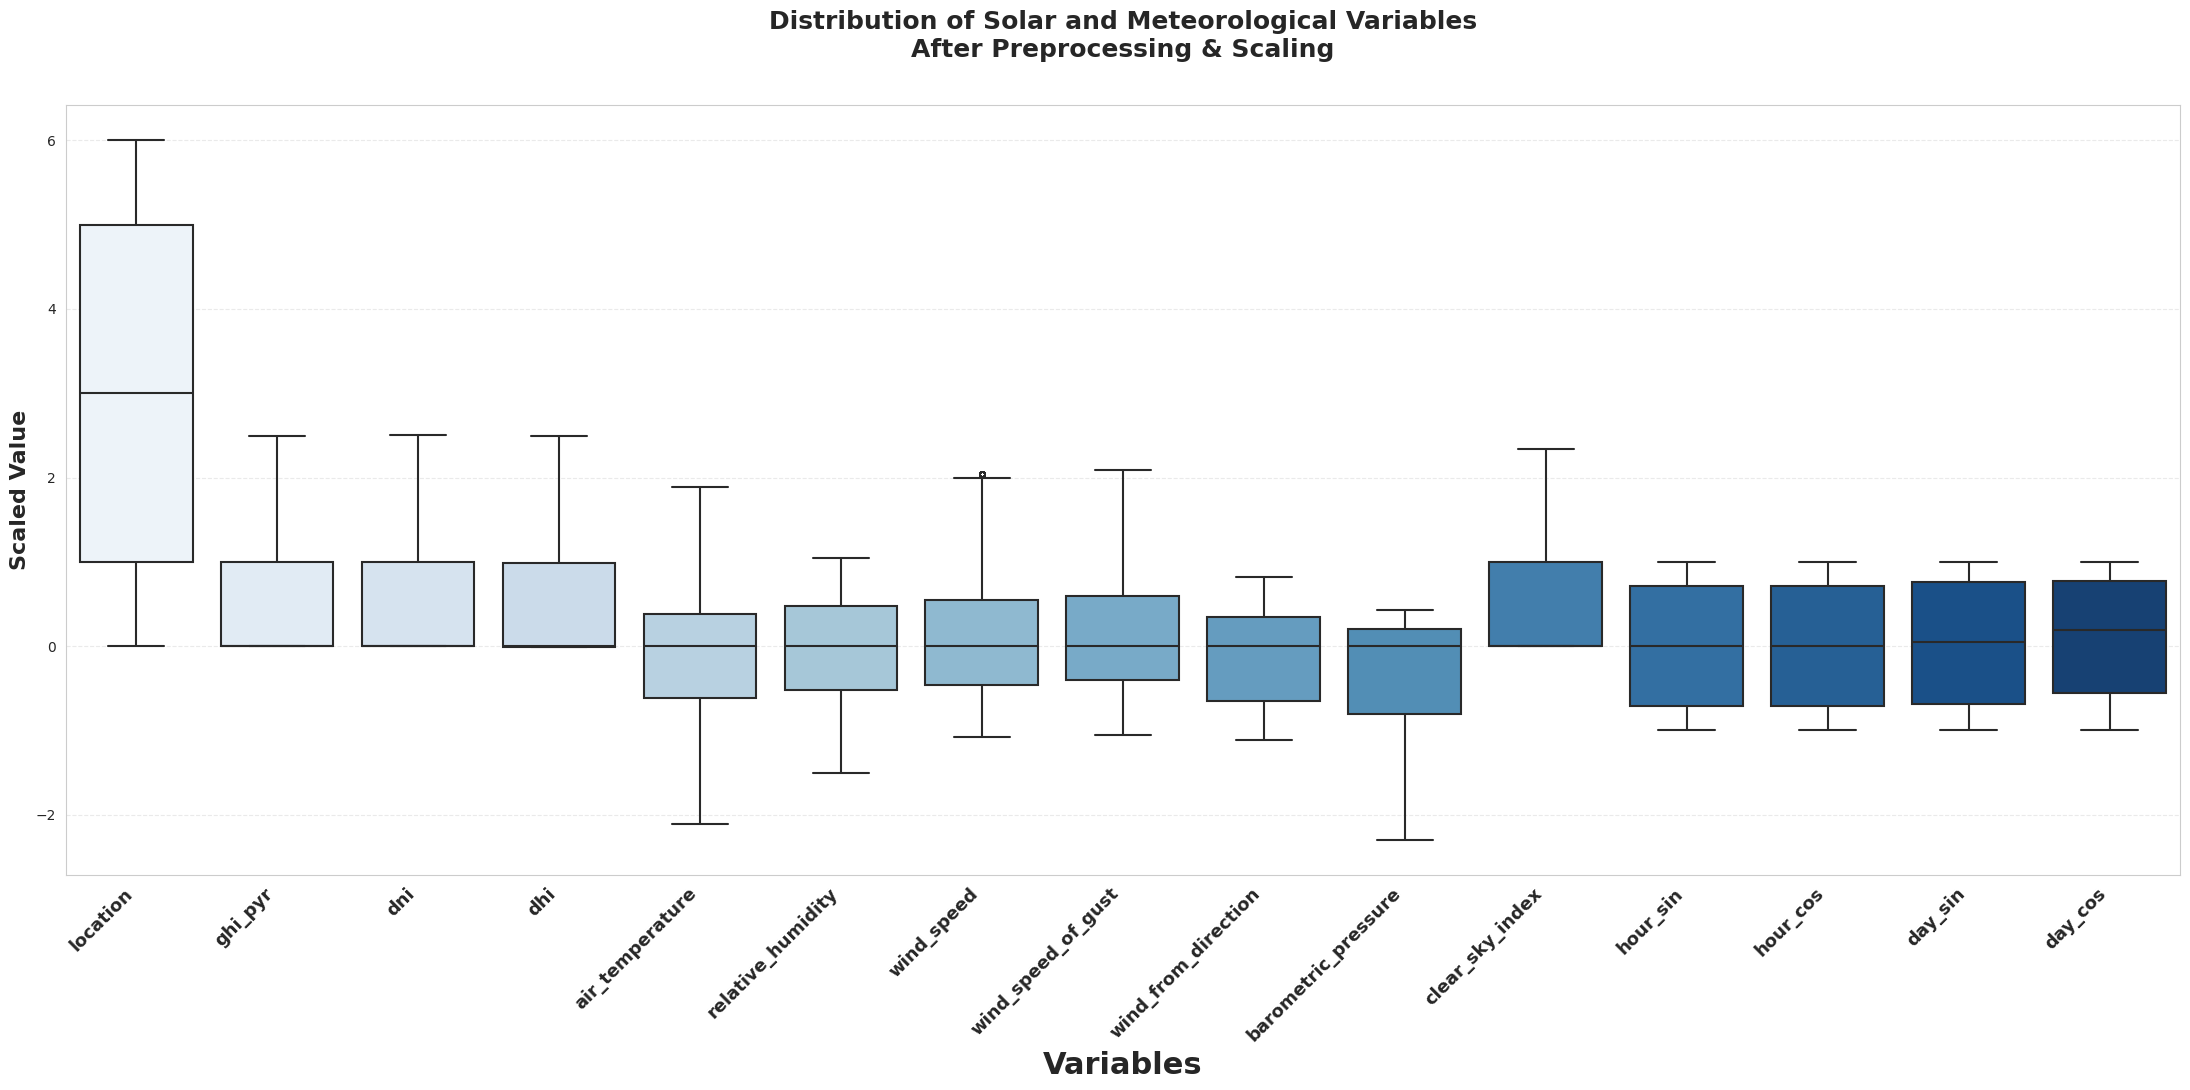

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import RobustScaler, LabelEncoder

# ========================== PREPROCESSING ==========================
df = pd.read_csv("/content/pakistan_solar_measurements_all_locations_merged.csv", low_memory=False)

# Drop unnecessary columns
df = df.drop(columns=['comments', 'sensor_cleaning', 'ghi_rsi'])

# Convert time
df['time'] = pd.to_datetime(df['time'], errors='coerce')

# Fill missing values
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df['location'] = df['location'].fillna(df['location'].mode()[0])

# Encode location
le = LabelEncoder()
df['location'] = le.fit_transform(df['location'])

# Feature Engineering
df['hour'] = df['time'].dt.hour
df['day_of_year'] = df['time'].dt.dayofyear

df['ghi_max_day'] = df.groupby(df['day_of_year'])['ghi_pyr'].transform('max')
df['clear_sky_index'] = df['ghi_pyr'] / df['ghi_max_day']
df.drop(columns=['ghi_max_day'], inplace=True)

df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_year']/366)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_year']/366)
df = df.drop(columns=['hour','day_of_year'])

# Outlier Handling
gust_lower, gust_upper = df['wind_speed_of_gust'].quantile([0.01, 0.99])
pressure_lower, pressure_upper = df['barometric_pressure'].quantile([0.01, 0.99])
df = df[(df['wind_speed_of_gust'] >= gust_lower) & (df['wind_speed_of_gust'] <= gust_upper)]
df = df[(df['barometric_pressure'] >= pressure_lower) & (df['barometric_pressure'] <= pressure_upper)]

numeric_cols = df.select_dtypes(include='number').columns
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
df[numeric_cols] = df[numeric_cols].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR, axis=1)

for col in ['wind_speed_of_gust','barometric_pressure']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower, upper=upper)

# Scaling
scale_cols = ['ghi_pyr','dni','dhi','air_temperature','relative_humidity',
              'wind_speed','wind_speed_of_gust','wind_from_direction',
              'barometric_pressure','clear_sky_index']
scaler = RobustScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# ========================== BLUE BOXPLOT AFTER PREPROCESSING ==========================
plt.figure(figsize=(22, 11))

sns.set_style("whitegrid")

columns_to_plot = [
    'location', 'ghi_pyr', 'dni', 'dhi', 'air_temperature',
    'relative_humidity', 'wind_speed', 'wind_speed_of_gust',
    'wind_from_direction', 'barometric_pressure', 'clear_sky_index',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos'
]

df_melt = pd.melt(df[columns_to_plot], var_name='Variable', value_name='Value')

palette = sns.color_palette("Blues", n_colors=len(columns_to_plot))

ax = sns.boxplot(x='Variable', y='Value', data=df_melt,
                 palette=palette,
                 fliersize=4,
                 linewidth=1.5)

# Box styling
for i, box in enumerate(ax.artists):
    box.set_edgecolor('navy')
    box.set_facecolor(palette[i])
    ax.lines[i*6 + 4].set_color('darkred')
    ax.lines[i*6 + 4].set_linewidth(2.8)

plt.title('Distribution of Solar and Meteorological Variables\nAfter Preprocessing & Scaling',
          fontsize=18, pad=35, fontweight='bold')

plt.ylabel('Scaled Value', fontsize=16, fontweight='bold')
plt.xlabel('Variables', fontsize=22, fontweight='bold')

# ←←← X-axis labels ←←←
plt.xticks(rotation=45,
           ha='right',
           fontsize=13,           # bada font size
           fontweight='bold')     # bold

plt.grid(True, axis='y', alpha=0.4, linestyle='--')

plt.tight_layout()

plt.savefig('boxplot_after_preprocessing_blues_final.png', dpi=400, bbox_inches='tight')
plt.show()

# PREPROCESSING

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, LabelEncoder

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("/content/pakistan_solar_measurements_all_locations_merged.csv", low_memory=False)

# -----------------------------
# Drop unnecessary columns
# -----------------------------
df = df.drop(columns=['comments', 'sensor_cleaning', 'ghi_rsi'])

# -----------------------------
# Convert time column to datetime
# -----------------------------
df['time'] = pd.to_datetime(df['time'], errors='coerce')

# -----------------------------
# Fill missing values
# -----------------------------
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df['location'] = df['location'].fillna(df['location'].mode()[0])

# -----------------------------
# Encode location (label encoding, do not scale)
# -----------------------------
le = LabelEncoder()
df['location'] = le.fit_transform(df['location'])

# -----------------------------
# Feature Engineering
# -----------------------------
df['hour'] = df['time'].dt.hour
df['day_of_year'] = df['time'].dt.dayofyear

# Clear sky index
df['ghi_max_day'] = df.groupby(df['day_of_year'])['ghi_pyr'].transform('max')
df['clear_sky_index'] = df['ghi_pyr'] / df['ghi_max_day']
df.drop(columns=['ghi_max_day'], inplace=True)

# Cyclical time features
df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_year']/366)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_year']/366)
df = df.drop(columns=['hour','day_of_year'])

# Define thresholds
gust_lower, gust_upper = df['wind_speed_of_gust'].quantile([0.01, 0.99])
pressure_lower, pressure_upper = df['barometric_pressure'].quantile([0.01, 0.99])

# Remove rows outside these bounds
df = df[(df['wind_speed_of_gust'] >= gust_lower) & (df['wind_speed_of_gust'] <= gust_upper)]
df = df[(df['barometric_pressure'] >= pressure_lower) & (df['barometric_pressure'] <= pressure_upper)]

print("Remaining rows after removing extreme outliers:", len(df))

# -----------------------------
# Outlier Handling (strict for volatile columns)
# -----------------------------
numeric_cols = df.select_dtypes(include='number').columns
# Clip all numeric columns using IQR
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
df[numeric_cols] = df[numeric_cols].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR, axis=1)

# Stricter winsorization for the volatile columns
for col in ['wind_speed_of_gust','barometric_pressure']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower, upper=upper)

# -----------------------------
# Scale numeric weather features (exclude location and cyclical features)
# -----------------------------

scale_cols = ['ghi_pyr','dni','dhi','air_temperature','relative_humidity',
              'wind_speed','wind_speed_of_gust','wind_from_direction','barometric_pressure','clear_sky_index']
scaler = RobustScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# -----------------------------
# Sort by time
# -----------------------------
df = df.sort_values('time').reset_index(drop=True)

# -----------------------------
# Train-test split (chronological)
# -----------------------------
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

# -----------------------------
# Input (X) and target (y)
# -----------------------------
drop_cols = ['time']  # target + time
X_train = train_df.drop(columns=drop_cols)
y_train = train_df['ghi_pyr']
X_test = test_df.drop(columns=drop_cols)
y_test = test_df['ghi_pyr']

# -----------------------------
# RNN/LSTM sequence preparation
# -----------------------------
def create_sequences(data, sequence_length, target_col_index):
    X_seq, y_seq = [], []
    for i in range(len(data) - sequence_length):
        X_seq.append(data[i:i+sequence_length])
        y_seq.append(data[i+sequence_length, target_col_index])
    return np.array(X_seq), np.array(y_seq)

X_train_np = X_train.values
X_test_np = X_test.values
target_index = X_train.columns.get_loc('ghi_pyr')  # example, can change to 'ghi_pyr'
sequence_length = 24

X_train_seq, y_train_seq = create_sequences(X_train_np, sequence_length, target_index)
X_test_seq, y_test_seq = create_sequences(X_test_np, sequence_length, target_index)

print("Updated Pipeline with full outlier handling complete!")


Remaining rows after removing extreme outliers: 741340
Updated Pipeline with full outlier handling complete!


Missing values per column:
time                   0
location               0
ghi_pyr                0
dni                    0
dhi                    0
air_temperature        0
relative_humidity      0
wind_speed             0
wind_speed_of_gust     0
wind_from_direction    0
barometric_pressure    0
clear_sky_index        0
hour_sin               0
hour_cos               0
day_sin                0
day_cos                0
dtype: int64

Number of outliers per numeric column after updated pipeline:
location                   0
ghi_pyr                    0
dni                        0
dhi                        0
air_temperature            0
relative_humidity          0
wind_speed             21260
wind_speed_of_gust         0
wind_from_direction        0
barometric_pressure        0
clear_sky_index            0
hour_sin                   0
hour_cos                   0
day_sin                    0
day_cos                    0
dtype: int64

Min and Max values per numeric column (roughly s

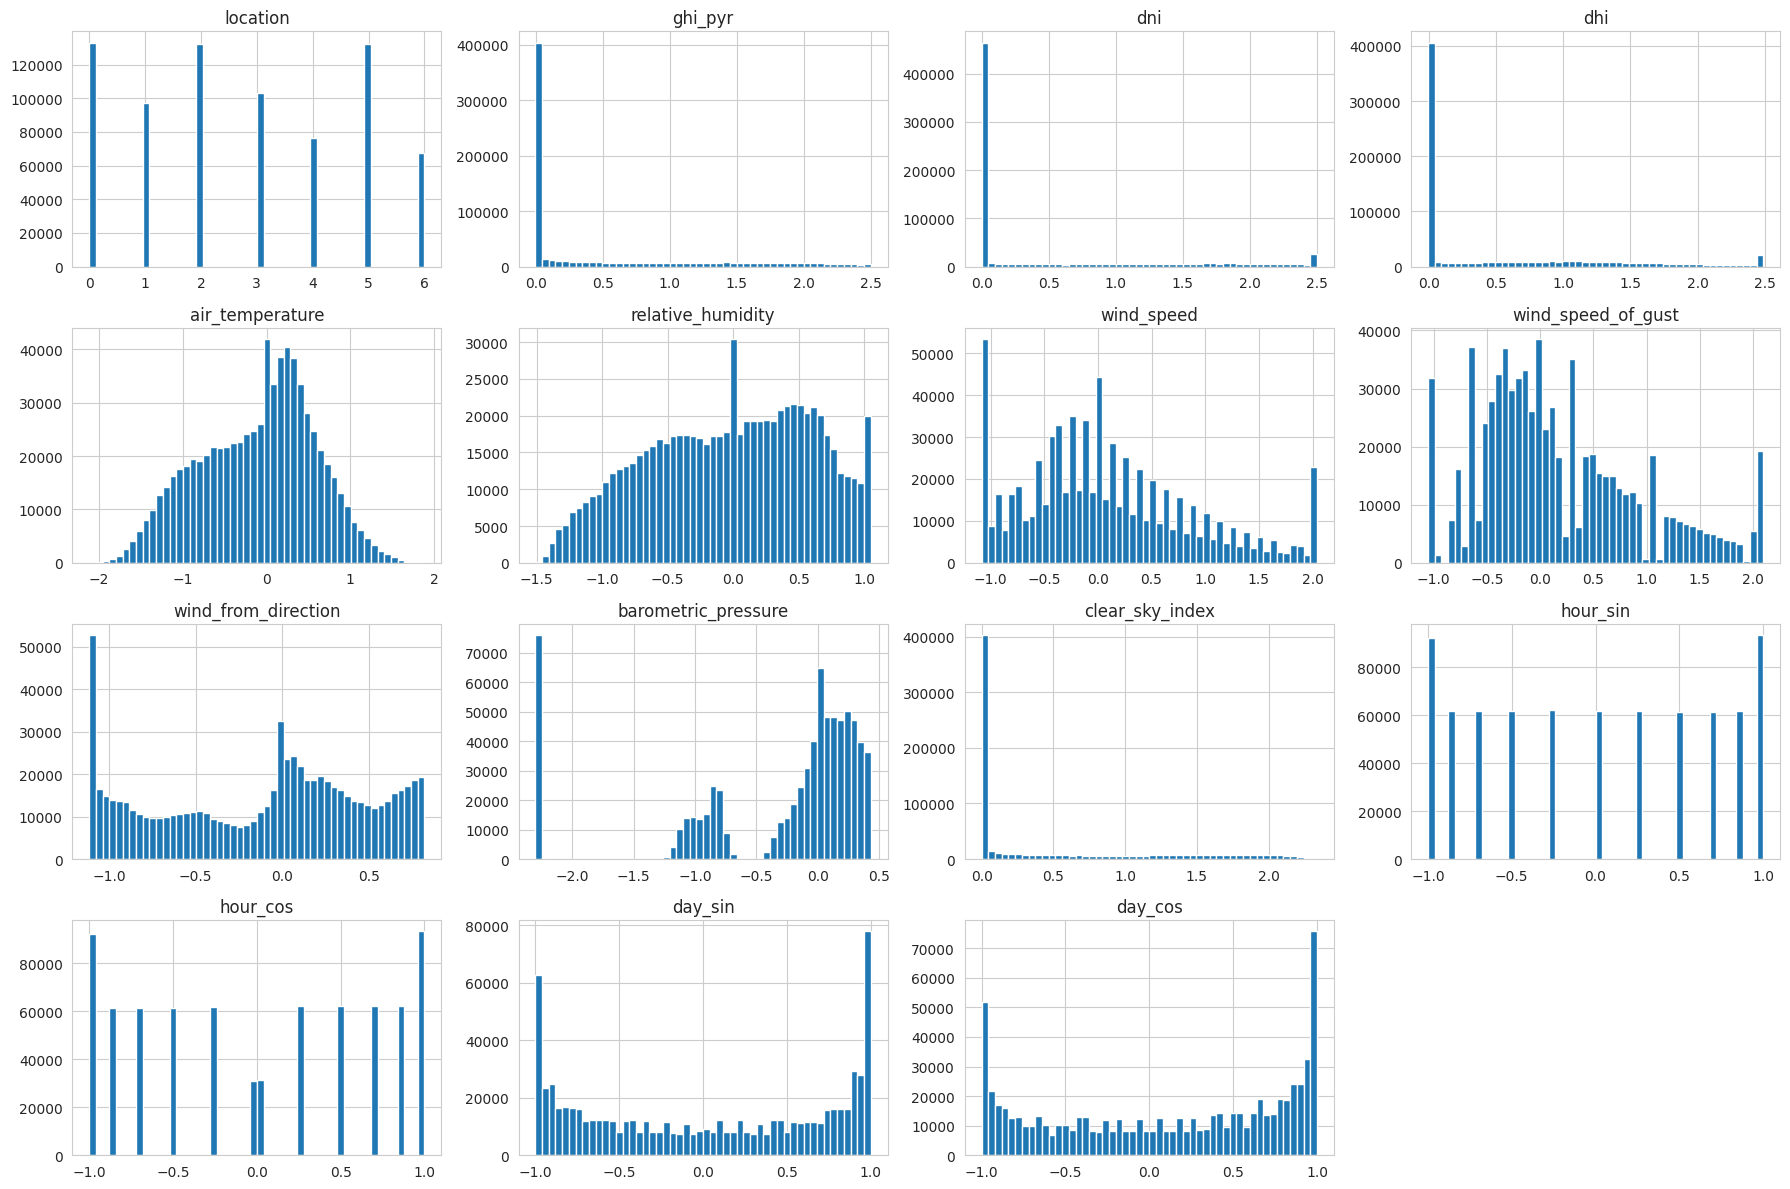

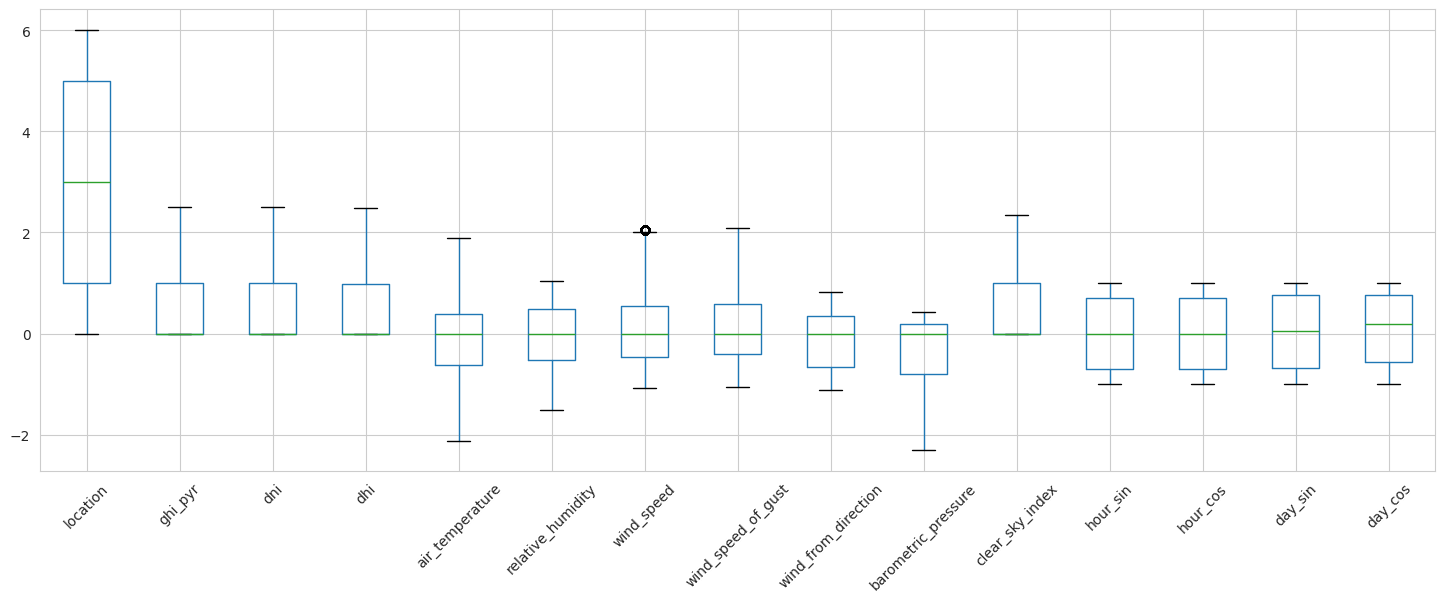

In [ ]:
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Missing values
# -----------------------------
print("Missing values per column:")
print(df.isnull().sum())

# -----------------------------
# 2️⃣ Outliers (IQR method)
# -----------------------------
numeric_cols = df.select_dtypes(include='number').columns
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[numeric_cols] < (Q1 - 1.5*IQR)) | (df[numeric_cols] > (Q3 + 1.5*IQR)))
print("\nNumber of outliers per numeric column after updated pipeline:")
print(outliers.sum())

# -----------------------------
# 3️⃣ Scaling statistics
# -----------------------------
print("\nMin and Max values per numeric column (roughly scaled):")
print(df[numeric_cols].agg(['min','max']))

print("\nMean and Std per numeric column:")
print(df[numeric_cols].agg(['mean','std']))

# -----------------------------
# 4️⃣ New features sample
# -----------------------------
print("\nSample of new features:")
print(df[['location','hour_sin','hour_cos','day_sin','day_cos','clear_sky_index']].head())

# -----------------------------
# 5️⃣ Quick visualization
# -----------------------------
df[numeric_cols].hist(figsize=(18,12), bins=50)
plt.tight_layout()
plt.show()

df[numeric_cols].boxplot(figsize=(18,6))
plt.xticks(rotation=45)
plt.show()

In [ ]:
import numpy as np

# -----------------------------
# Select input features (X) and target (y)
# -----------------------------

feature_cols = [
    'location', 'ghi_pyr',
    'dni', 'dhi', 'air_temperature', 'relative_humidity',
    'wind_speed', 'wind_speed_of_gust', 'wind_from_direction',
    'barometric_pressure', 'clear_sky_index',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos'
]
target_col = 'ghi_pyr'

# Convert to numpy
X_train_np = X_train[feature_cols].values
y_train_np = y_train.values

X_test_np  = X_test[feature_cols].values
y_test_np = y_test.values

# -----------------------------
# Sequence creation function
# -----------------------------
def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])
    return np.array(X_seq), np.array(y_seq)

sequence_length = 24  # past 24 hours

X_train_seq, y_train_seq = create_sequences(X_train_np, y_train_np, sequence_length)
X_test_seq, y_test_seq = create_sequences(X_test_np, y_test_np, sequence_length)

print("Train shape:", X_train_seq.shape)
print("Test shape:", X_test_seq.shape)

Train shape: (593048, 24, 15)
Test shape: (148244, 24, 15)


# LSTM MODEL

In [ ]:
# =====================================
# FINAL TUNED LSTM MODEL
# =====================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# -------------------------------------
# Input shape
# -------------------------------------
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])

# -------------------------------------
# Build model (2-layer LSTM, 48 -> 24 nodes)
# -------------------------------------
model = Sequential([
    Input(shape=input_shape),

    # First LSTM layer
    LSTM(48, return_sequences=True, activation='tanh', recurrent_dropout=0.1),
    Dropout(0.25),

    # Second LSTM layer
    LSTM(24, activation='tanh', recurrent_dropout=0.1),
    Dropout(0.25),

    # Output layer
    Dense(1)
])

# -------------------------------------
# Optimizer with lower learning rate
# -------------------------------------
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse'
)

model.summary()

# -------------------------------------
# Early stopping
# -------------------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# -------------------------------------
# Train model
# -------------------------------------
history = model.fit(
    X_train_seq,
    y_train_seq,
    epochs=100,           # longer training for better convergence
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# -------------------------------------
# Predictions
# -------------------------------------
y_pred = model.predict(X_test_seq).flatten()

# -------------------------------------
# Evaluation Metrics
# -------------------------------------
MAE  = mean_absolute_error(y_test_seq, y_pred)
MSE  = mean_squared_error(y_test_seq, y_pred)
RMSE = np.sqrt(MSE)
R2   = r2_score(y_test_seq, y_pred)

print("\n==============================")
print("FINAL TUNED LSTM MODEL RESULTS")
print("==============================")
print(f"MAE  : {MAE:.4f}")
print(f"MSE  : {MSE:.4f}")
print(f"RMSE : {RMSE:.4f}")
print(f"R²   : {R2:.4f}")


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 48)         │        12,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 24)             │         7,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,321 (75.47 KB)

 Trainable params: 19,321 (75.47 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 58s 43ms/step - loss: 0.0902 - val_loss: 0.0309
Epoch 2/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 80s 42ms/step - loss: 0.0269 - val_loss: 0.0249
Epoch 3/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - loss: 0.0229 - val_loss: 0.0243
Epoch 4/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - loss: 0.0204 - val_loss: 0.0208
Epoch 5/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - loss: 0.0190 - val_loss: 0.0204
Epoch 6/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - loss: 0.0181 - val_loss: 0.0198
Epoch 7/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - loss: 0.0181 - val_loss: 0.0192
Epoch 8/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - loss: 0.0173 - val_loss: 0.0188
Epoch 9/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - loss: 0.0169 - val_loss: 0.0188
Epoch 10/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - loss: 0.0168 - val_loss: 0.0188
Epoch 11/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - loss: 0.0166 - val_loss: 0.02

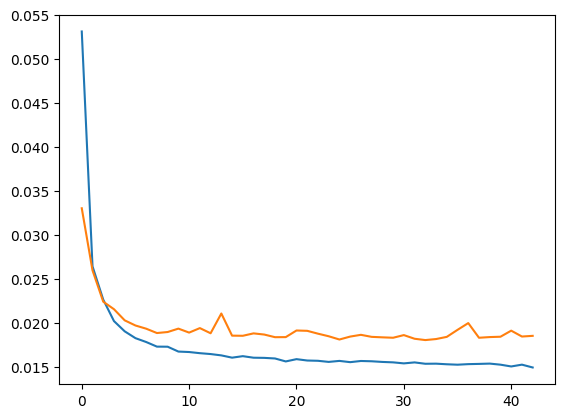

In [ ]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

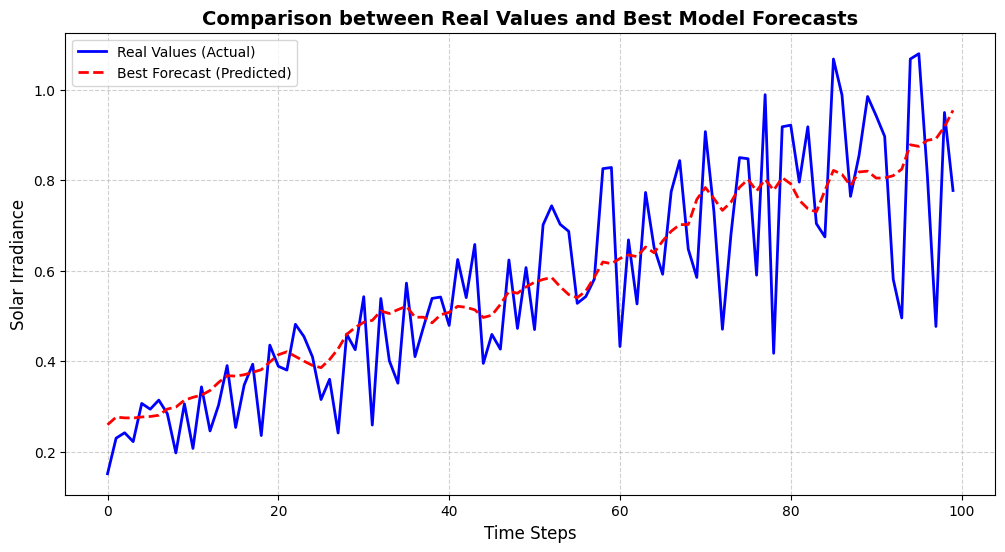

In [ ]:
import matplotlib.pyplot as plt

# Graph 1: Actual vs Predicted
plt.figure(figsize=(12, 6))

plt.plot(y_test_seq[:100], label='Real Values (Actual)', color='blue', linewidth=2)
plt.plot(y_pred[:100], label='Best Forecast (Predicted)', color='red', linestyle='--', linewidth=2)

plt.title('Comparison between Real Values and Best Model Forecasts', fontsize=14, fontweight='bold')
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Solar Irradiance', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('actual_vs_predicted_final.png', dpi=300)
plt.show()

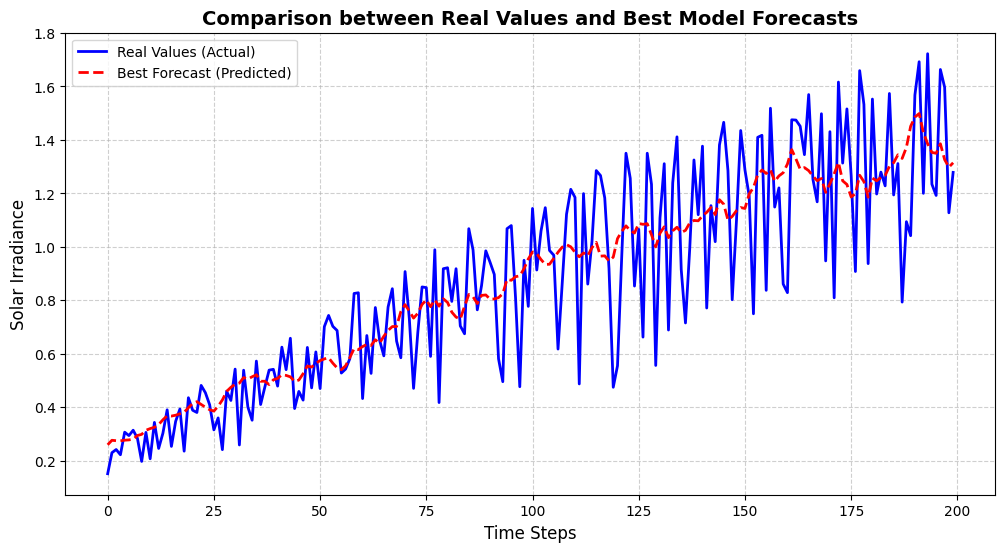

In [ ]:
import matplotlib.pyplot as plt

# Graph 1: Actual vs Predicted
plt.figure(figsize=(12, 6))

plt.plot(y_test_seq[:200], label='Real Values (Actual)', color='blue', linewidth=2)
plt.plot(y_pred[:200], label='Best Forecast (Predicted)', color='red', linestyle='--', linewidth=2)

plt.title('Comparison between Real Values and Best Model Forecasts', fontsize=14, fontweight='bold')
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Solar Irradiance', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('actual_vs_predicted_final.png', dpi=300)
plt.show()

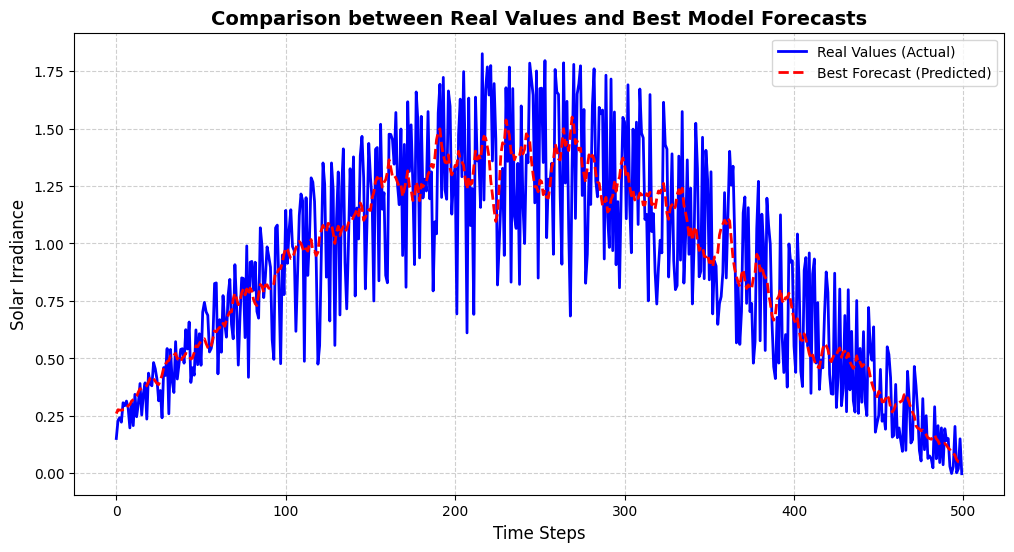

In [ ]:
import matplotlib.pyplot as plt

# Graph 1: Actual vs Predicted
plt.figure(figsize=(12, 6))

plt.plot(y_test_seq[:500], label='Real Values (Actual)', color='blue', linewidth=2)
plt.plot(y_pred[:500], label='Best Forecast (Predicted)', color='red', linestyle='--', linewidth=2)

plt.title('Comparison between Real Values and Best Model Forecasts', fontsize=14, fontweight='bold')
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Solar Irradiance', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('actual_vs_predicted_final.png', dpi=300)
plt.show()

# GRU MODEL

In [ ]:
!pip install tensorflow[and-cuda]   # if you want GPU support (and the env has cuda)

In [ ]:
# ===============================
# GRU MODEL FOR SOLAR POWER PREDICTION
# ===============================

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# Model Definition
# -----------------------------
gru_model = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),  # (24, 14)

    GRU(64, return_sequences=True),
    Dropout(0.2),

    GRU(32),
    Dropout(0.2),

    Dense(1)  # Regression output
])

# -----------------------------
# Compile Model
# -----------------------------
gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)
gru_model.summary()

# -----------------------------
# Callbacks
# -----------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# -----------------------------
# Train Model
# -----------------------------
history = gru_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


# -----------------------------
# Evaluation on Test Data
# -----------------------------
y_pred = gru_model.predict(X_test_seq).ravel()

mae  = mean_absolute_error(y_test_seq, y_pred)
mse  = mean_squared_error(y_test_seq, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_seq, y_pred)

print("\nGRU Model Performance on Test Set")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_8 (GRU)                     │ (None, 24, 64)         │        15,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_9 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,993 (97.63 KB)

 Trainable params: 24,993 (97.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 147s 13ms/step - loss: 0.0767 - val_loss: 0.0279
Epoch 2/50
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 144s 13ms/step - loss: 0.0638 - val_loss: 0.0278
Epoch 3/50
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 144s 13ms/step - loss: 0.0622 - val_loss: 0.0278
Epoch 4/50
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 145s 13ms/step - loss: 0.0615 - val_loss: 0.0277
Epoch 5/50
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 144s 13ms/step - loss: 0.0614 - val_loss: 0.0278
Epoch 6/50
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 147s 13ms/step - loss: 0.0606 - val_loss: 0.0292
Epoch 7/50
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 146s 13ms/step - loss: 0.0611 - val_loss: 0.0275
Epoch 8/50
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 145s 13ms/step - loss: 0.0600 - val_loss: 0.0271
Epoch 9/50
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 145s 13ms/step - loss: 0.0599 - val_loss: 0.0273
Epoch 10/50
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 145s 13ms/step - loss: 0.0597 - val_loss: 0.0275
Epoch 11/50
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 145s 13ms/step - loss: 0

NameError: name 'model' is not defined

In [ ]:
# -----------------------------
# Evaluation on Test Data
# -----------------------------
y_pred = gru_model.predict(X_test_seq).ravel()

mae  = mean_absolute_error(y_test_seq, y_pred)
mse  = mean_squared_error(y_test_seq, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_seq, y_pred)

print("\nGRU Model Performance on Test Set")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

6204/6204 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step

GRU Model Performance on Test Set
MAE  : 0.0968
MSE  : 0.0390
RMSE : 0.1974
R²   : 0.9221


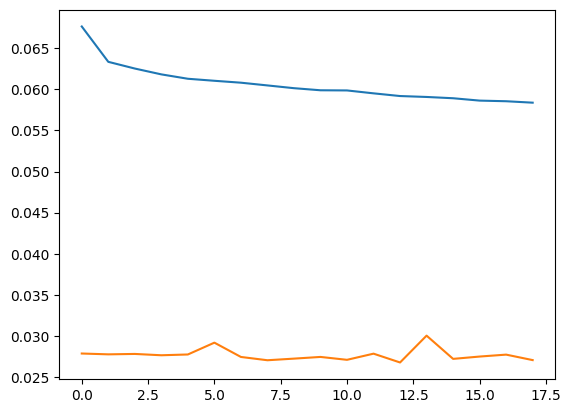

In [ ]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

# TCN MODEL

In [ ]:
!pip install keras-tcn


In [ ]:
# =====================================
# TCN MODEL v1: Lightweight & Stable
# =====================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tcn import TCN
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------------------
# Input shape
# -------------------------------------
input_shape = X_train_seq.shape[1:]  # (24, num_features)

# -------------------------------------
# Build TCN Model
# -------------------------------------
model = Sequential([
    TCN(
        nb_filters=32,
        kernel_size=3,
        dilations=[1, 2, 4, 8],
        activation='relu',
        padding='causal',
        use_skip_connections=True,
        return_sequences=False,
        input_shape=input_shape
    ),
    Dropout(0.2),
    Dense(1)
])

# -------------------------------------
# Compile
# -------------------------------------
model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='mse'
)

model.summary()

# -------------------------------------
# Training
# -------------------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=2
)

# -------------------------------------
# Evaluation
# -------------------------------------
y_pred = model.predict(X_test_seq).ravel()

MAE  = mean_absolute_error(y_test_seq, y_pred)
MSE  = mean_squared_error(y_test_seq, y_pred)
RMSE = np.sqrt(MSE)
R2   = r2_score(y_test_seq, y_pred)

print("\nTCN v1 Results")
print(f"MAE  : {MAE:.4f}")
print(f"MSE  : {MSE:.4f}")
print(f"RMSE : {RMSE:.4f}")
print(f"R²   : {R2:.4f}")


/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tcn_4 (TCN)                     │ (None, 32)             │        23,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,745 (92.75 KB)

 Trainable params: 23,745 (92.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
9927/9927 - 201s - 20ms/step - loss: 0.4401 - val_loss: 0.0524
Epoch 2/100
9927/9927 - 196s - 20ms/step - loss: 0.0774 - val_loss: 0.0508
Epoch 3/100
9927/9927 - 196s - 20ms/step - loss: 0.0743 - val_loss: 0.0501
Epoch 4/100
9927/9927 - 203s - 20ms/step - loss: 0.0741 - val_loss: 0.0524
Epoch 5/100
9927/9927 - 200s - 20ms/step - loss: 0.0734 - val_loss: 0.0482
Epoch 6/100
9927/9927 - 194s - 20ms/step - loss: 0.0723 - val_loss: 0.0494
Epoch 7/100
9927/9927 - 194s - 20ms/step - loss: 0.0719 - val_loss: 0.0500
Epoch 8/100
9927/9927 - 194s - 20ms/step - loss: 0.0715 - val_loss: 0.0485
Epoch 9/100
9927/9927 - 202s - 20ms/step - loss: 0.0710 - val_loss: 0.0483
Epoch 10/100
9927/9927 - 202s - 20ms/step - loss: 0.0701 - val_loss: 0.0484
Epoch 11/100
9927/9927 - 195s - 20ms/step - loss: 0.0699 - val_loss: 0.0483
Epoch 12/100
9927/9927 - 194s - 20ms/step - loss: 0.0695 - val_loss: 0.0486
Epoch 13/100
9927/9927 - 193s - 19ms/step - loss: 0.0692 - val_loss: 0.0494
Epoch 14/100
9927/992

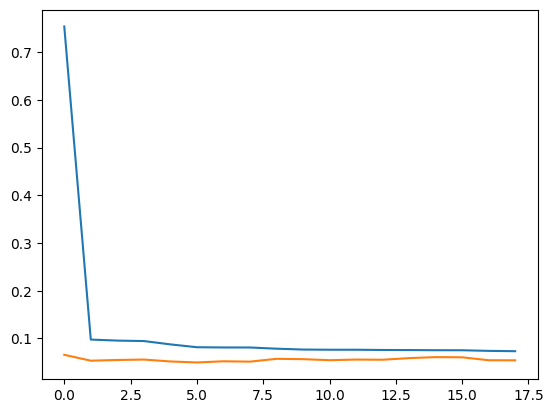

In [ ]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

# INFORMER

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 24, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding_3           │ (None, 24, 64)         │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ informer_encoder_layer_6        │ (None, 24, 64)         │        33,472 │
│ (InformerEncoderLayer)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ distilling_layer_5              │ (None, 12, 64)         │        12,352 │
│ (DistillingLayer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 12, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ informer_encoder_layer_7        │ (None, 12, 32)         │         8,544 │
│ (InformerEncoderLayer)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,505 (224.63 KB)

 Trainable params: 57,505 (224.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 49s 13ms/step - loss: 0.0678 - val_loss: 0.0510
Epoch 2/40
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.0600 - val_loss: 0.0485
Epoch 3/40
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0583 - val_loss: 0.0477
Epoch 4/40
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 0.0575 - val_loss: 0.0470
Epoch 5/40
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0570 - val_loss: 0.0467
Epoch 6/40
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0566 - val_loss: 0.0472
Epoch 7/40
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0563 - val_loss: 0.0482
Epoch 8/40
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0559 - val_loss: 0.0481
Epoch 9/40
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0557 - val_loss: 0.0469
Epoch 10/40
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0555 - val_loss: 0.0466
Epoch 11/40
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0552 - val_loss: 0.0464
Epoch 12/40
2482/2

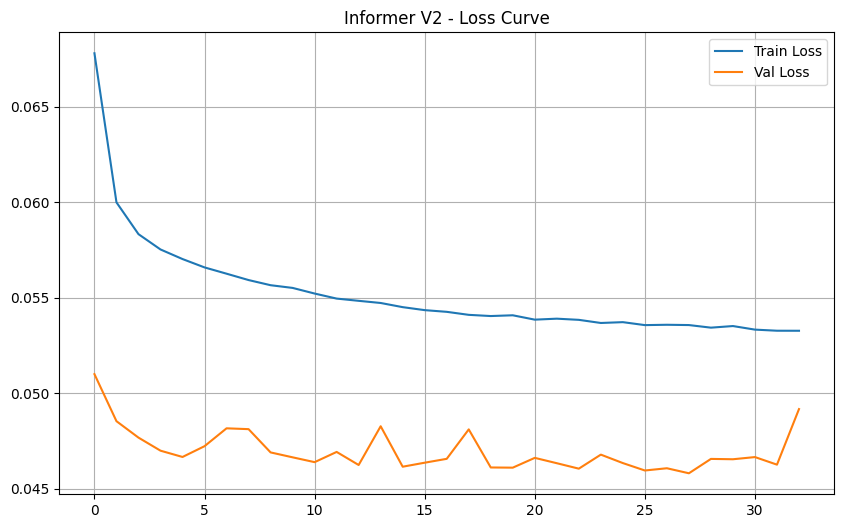

In [ ]:
# =====================================
# INFORMER MODEL - VERSION 2 (Lightweight & Efficient)
# =====================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Conv1D, MaxPooling1D,
    GlobalAveragePooling1D, MultiHeadAttention,
    LayerNormalization, Layer
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])

class PositionalEncoding(Layer):
    def call(self, x):
        seq_len = tf.shape(x)[1]
        d_model = tf.shape(x)[2]
        positions = tf.cast(tf.range(seq_len)[:, tf.newaxis], tf.float32)
        dims = tf.cast(tf.range(d_model)[tf.newaxis, :], tf.float32)
        angle_rates = 1.0 / tf.pow(10000.0, (2 * (dims // 2)) / tf.cast(d_model, tf.float32))
        angle_rads = positions * angle_rates
        sines = tf.sin(angle_rads[:, 0::2])
        cosines = tf.cos(angle_rads[:, 1::2])
        pos_encoding = tf.reshape(tf.concat([sines[..., tf.newaxis], cosines[..., tf.newaxis]], axis=-1), (seq_len, d_model))
        return x + pos_encoding[tf.newaxis, ...]

class InformerEncoderLayer(Layer):
    def __init__(self, d_model, num_heads=4, ff_dim=None, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        ff_dim = ff_dim or d_model * 2
        self.attn = MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation='relu'),
            Dense(d_model)
        ])
        self.norm1 = LayerNormalization()
        self.norm2 = LayerNormalization()
        self.drop1 = Dropout(dropout)
        self.drop2 = Dropout(dropout)

    def call(self, x, training=None):
        attn_out = self.attn(x, x, x, training=training)
        x = self.norm1(x + self.drop1(attn_out, training=training))
        ffn_out = self.ffn(x, training=training)
        x = self.norm2(x + self.drop2(ffn_out, training=training))
        return x

class DistillingLayer(Layer):
    def __init__(self, d_model, **kwargs):
        super().__init__(**kwargs)
        self.conv = Conv1D(filters=d_model, kernel_size=3, padding='same', activation='relu')
        self.pool = MaxPooling1D(pool_size=2, strides=2, padding='same')
    def call(self, x):
        x = self.conv(x)
        return self.pool(x)

# ================== MODEL ==================
model = Sequential([
    Input(shape=input_shape),
    Dense(64),
    PositionalEncoding(),

    InformerEncoderLayer(d_model=64, num_heads=4, dropout=0.1),
    DistillingLayer(d_model=64),
    Dropout(0.15),

    Dense(32),
    InformerEncoderLayer(d_model=32, num_heads=4, dropout=0.1),
    Dropout(0.15),

    GlobalAveragePooling1D(),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.0008),   # Higher LR for faster convergence
    loss='mse'
)

model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=40,
    batch_size=256,           # Larger batch
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

model.save("informer_version2_lightweight.keras")

y_pred = model.predict(X_test_seq).flatten()

MAE = mean_absolute_error(y_test_seq, y_pred)
RMSE = np.sqrt(mean_squared_error(y_test_seq, y_pred))
R2 = r2_score(y_test_seq, y_pred)

print("\n" + "="*50)
print("INFORMER VERSION 2 RESULTS (Lightweight)")
print("="*50)
print(f"MAE  : {MAE:.5f}")
print(f"RMSE : {RMSE:.5f}")
print(f"R²   : {R2:.5f}")

plt.figure(figsize=(10,6))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Informer V2 - Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

# AUTOTRANSFORMER

In [ ]:
# =====================================
# AUTOFORMER - VERSION 3 (Lightweight & Fast)
# =====================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Dense, Dropout, GlobalAveragePooling1D, Layer
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])

# (Same classes as above)

model = Sequential([
    Input(shape=input_shape),
    Dense(48),
    PositionalEncoding(),

    AutoformerEncoderLayer(d_model=48, num_heads=4, dropout=0.08, moving_avg=3),
    Dropout(0.15),

    Dense(24),
    AutoformerEncoderLayer(d_model=24, num_heads=4, dropout=0.08, moving_avg=3),
    Dropout(0.15),

    GlobalAveragePooling1D(),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.0007), loss='mse')
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history = model.fit(X_train_seq, y_train_seq, epochs=40, batch_size=256,
                    validation_split=0.2, callbacks=[early_stop], verbose=1)

model.save("autoformer_version3_lightweight.keras")

y_pred = model.predict(X_test_seq).flatten()
MAE = mean_absolute_error(y_test_seq, y_pred)
RMSE = np.sqrt(mean_squared_error(y_test_seq, y_pred))
R2 = r2_score(y_test_seq, y_pred)

print("\n" + "="*50)
print("AUTOFORMER V3 (Lightweight) RESULTS")
print("="*50)
print(f"MAE  : {MAE:.5f}")
print(f"RMSE : {RMSE:.5f}")
print(f"R²   : {R2:.5f}")

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 24, 48)         │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding_2           │ (None, 24, 48)         │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ autoformer_encoder_layer_4      │ (None, 24, 48)         │        18,768 │
│ (AutoformerEncoderLayer)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 24, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 24, 24)         │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ autoformer_encoder_layer_5      │ (None, 24, 24)         │         4,776 │
│ (AutoformerEncoderLayer)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 24, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 24)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,513 (99.66 KB)

 Trainable params: 25,513 (99.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 49s 13ms/step - loss: 0.0897 - val_loss: 0.0539
Epoch 2/40
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.0655 - val_loss: 0.0691
Epoch 3/40
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.0634 - val_loss: 0.0669
Epoch 4/40
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.0626 - val_loss: 0.0671
Epoch 5/40
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0622 - val_loss: 0.0663
Epoch 6/40
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.0619 - val_loss: 0.0671
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
6204/6204 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step

AUTOFORMER V3 (Lightweight) RESULTS
MAE  : 0.12979
RMSE : 0.21561
R²   : 0.90709


# N BEAT

🔍 INPUT DATA DETAILS
X_train_seq shape : (794158, 24, 15)
y_train_seq shape : (794158,)
X_test_seq shape  : (198522, 24, 15)
y_test_seq shape  : (198522,)
Features     : 15 | Lookback : 24
Train samples: 794,158 | Test samples: 198,522
Target Mean  : 0.5293 | Std: 0.7483
Model Parameters: 5,390,454
Epoch  1 | Train: 0.09366 | Val: 0.04987 | LR: 2.00e-04
   ✅ Best model saved
Epoch  2 | Train: 0.06306 | Val: 0.04907 | LR: 2.00e-04
   ✅ Best model saved
Epoch  3 | Train: 0.06060 | Val: 0.05191 | LR: 2.00e-04
Epoch  4 | Train: 0.05979 | Val: 0.04790 | LR: 2.00e-04
   ✅ Best model saved
Epoch  5 | Train: 0.05900 | Val: 0.04810 | LR: 2.00e-04
Epoch  6 | Train: 0.05827 | Val: 0.04776 | LR: 2.00e-04
   ✅ Best model saved
Epoch  7 | Train: 0.05781 | Val: 0.04836 | LR: 2.00e-04
Epoch  8 | Train: 0.05701 | Val: 0.04789 | LR: 2.00e-04
Epoch  9 | Train: 0.05598 | Val: 0.04892 | LR: 2.00e-04
Epoch 10 | Train: 0.05475 | Val: 0.04893 | LR: 2.00e-04
Epoch 11 | Train: 0.05306 | Val: 0.04842 | LR: 1.00e

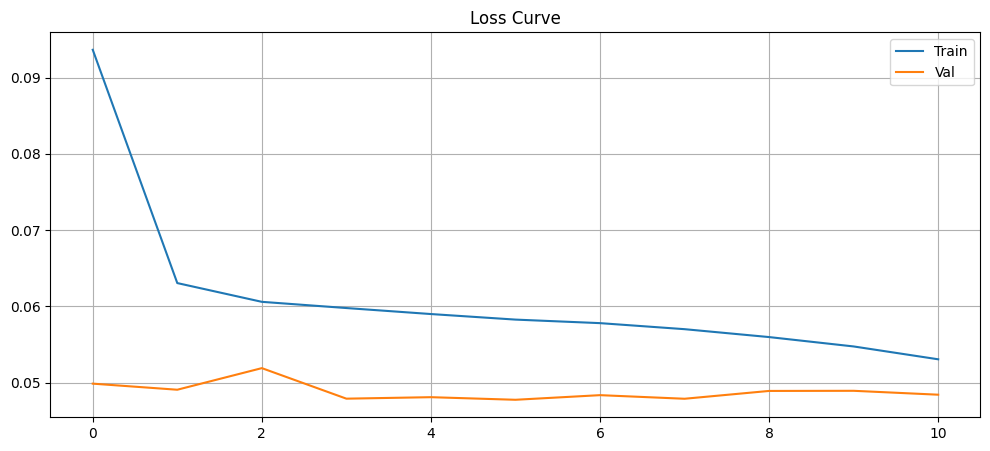

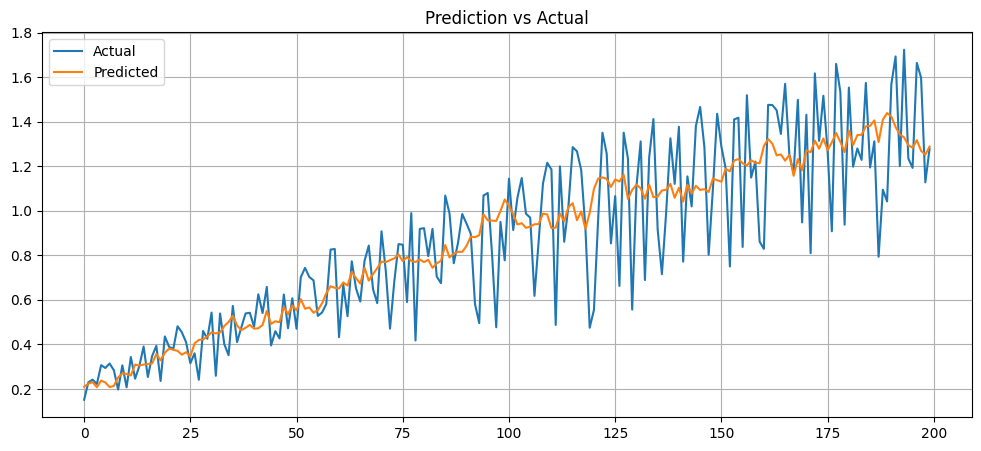

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import torch.optim as optim

# =========================
# INPUT DETAILS
# =========================
print("="*60)
print("🔍 INPUT DATA DETAILS")
print("="*60)
print(f"X_train_seq shape : {X_train_seq.shape}")
print(f"y_train_seq shape : {y_train_seq.shape}")
print(f"X_test_seq shape  : {X_test_seq.shape}")
print(f"y_test_seq shape  : {y_test_seq.shape}")
print(f"Features     : {X_train_seq.shape[2]} | Lookback : {X_train_seq.shape[1]}")
print(f"Train samples: {len(X_train_seq):,} | Test samples: {len(X_test_seq):,}")
print(f"Target Mean  : {y_train_seq.mean():.4f} | Std: {y_train_seq.std():.4f}")
print("="*60)

# =========================
# DATA
# =========================
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test_seq, dtype=torch.float32)

split = int(len(X_train_tensor) * 0.8)
X_tr, X_val = X_train_tensor[:split], X_train_tensor[split:]
y_tr, y_val = y_train_tensor[:split], y_train_tensor[split:]

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=128, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=128, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=128)

# =========================
# N-BEATS BLOCK
# =========================
class NBeatsBlock(nn.Module):
    def __init__(self, input_dim, hidden_dim=512, dropout=0.05):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
        )
        self.backcast = nn.Linear(hidden_dim, input_dim)
        self.forecast = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        h = self.net(x)
        return self.backcast(h), self.forecast(h)

# =========================
# MODEL (2 Stacks - Best so far)
# =========================
class NBeatsModel(nn.Module):
    def __init__(self, seq_len, n_features, hidden_dim=512, num_stacks=2, num_blocks=3):
        super().__init__()
        self.input_dim = seq_len * n_features
        self.stacks = nn.ModuleList()

        for _ in range(num_stacks):
            blocks = nn.ModuleList([NBeatsBlock(self.input_dim, hidden_dim) for _ in range(num_blocks)])
            self.stacks.append(blocks)

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        residual = x
        forecast_sum = 0.0

        for stack in self.stacks:
            stack_res = residual
            for block in stack:
                backcast, forecast = block(stack_res)
                stack_res = stack_res - backcast
                forecast_sum += forecast
            residual = stack_res

        return forecast_sum.squeeze()

# =========================
# INIT
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NBeatsModel(
    seq_len=X_train_seq.shape[1],
    n_features=X_train_seq.shape[2],
    hidden_dim=512,
    num_stacks=2,
    num_blocks=3
).to(device)

print(f"Model Parameters: {sum(p.numel() for p in model.parameters()):,}")

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

# =========================
# TRAINING
# =========================
patience = 5
best_val = float("inf")
counter = 0
best_path = "best_nbeats_final.pth"

train_losses, val_losses = [], []

epochs = 50

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()

        pred = model(xb)
        loss = criterion(pred, yb)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            val_loss += criterion(pred, yb).item()

    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:2d} | Train: {train_loss:.5f} | Val: {val_loss:.5f} | LR: {current_lr:.2e}")

    if val_loss < best_val:
        best_val = val_loss
        counter = 0
        torch.save(model.state_dict(), best_path)
        print("   ✅ Best model saved")
    else:
        counter += 1
        if counter >= patience:
            print("⛔ Early stopping")
            break

# =========================
# EVALUATION
# =========================
model.load_state_dict(torch.load(best_path))
model.eval()

preds, actuals = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = model(xb)
        preds.extend(out.cpu().numpy())
        actuals.extend(yb.numpy())

preds = np.array(preds)
actuals = np.array(actuals)

mae = mean_absolute_error(actuals, preds)
rmse = np.sqrt(mean_squared_error(actuals, preds))
r2 = r2_score(actuals, preds)

print("\n" + "="*50)
print("🏆 FINAL RESULTS")
print("="*50)
print(f"MAE  : {mae:.5f}")
print(f"RMSE : {rmse:.5f}")
print(f"R²   : {r2:.5f}")
print("="*50)

# Plots
plt.figure(figsize=(12,5))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.legend()
plt.title("Loss Curve")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(actuals[:200], label="Actual")
plt.plot(preds[:200], label="Predicted")
plt.legend()
plt.title("Prediction vs Actual")
plt.grid(True)
plt.show()

# Significance Test

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def run_experiment(seed):
    # Seed set
    tf.random.set_seed(seed)
    np.random.seed(seed)

    # Model architecture
    model = Sequential([
        Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
        LSTM(48, return_sequences=True, activation='tanh', recurrent_dropout=0.1),
        Dropout(0.25),
        LSTM(24, activation='tanh', recurrent_dropout=0.1),
        Dropout(0.25),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Training
    model.fit(X_train_seq, y_train_seq, epochs=35, batch_size=64,
              validation_split=0.2, callbacks=[early_stop], verbose=1)

    # Save weights
    model.save(f'/content/drive/MyDrive/lstm_run_seed_{seed}.keras')

    # Prediction and Metrics
    y_pred = model.predict(X_test_seq).flatten()
    mae = mean_absolute_error(y_test_seq, y_pred)
    mse = mean_squared_error(y_test_seq, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_seq, y_pred)

    return mae, mse, rmse, r2

# --- Run 5 times ---
seeds = [10, 42, 100, 123, 999]
all_mae = []

print("Starting 5-run statistical experiment...")

for s in seeds:
    mae, mse, rmse, r2 = run_experiment(s)
    all_mae.append(mae)
    print(f"Seed {s} Done: MAE = {mae:.4f}")

# Final output for your paper
print("\n===============================")
print("STATISTICAL SUMMARY FOR REVIEWER 2")
print("===============================")
print(f"Mean MAE : {np.mean(all_mae):.4f}")
print(f"Std Dev  : {np.std(all_mae):.4f}")
print(f"Result for paper: {np.mean(all_mae):.4f} ± {np.std(all_mae):.4f}")
print("===============================")

Starting 5-run statistical experiment...
Epoch 1/35
459/459 ━━━━━━━━━━━━━━━━━━━━ 74s 150ms/step - loss: 0.0467 - val_loss: 0.0216
Epoch 2/35
459/459 ━━━━━━━━━━━━━━━━━━━━ 66s 144ms/step - loss: 0.0233 - val_loss: 0.0196
Epoch 3/35
459/459 ━━━━━━━━━━━━━━━━━━━━ 65s 141ms/step - loss: 0.0204 - val_loss: 0.0180
Epoch 4/35
459/459 ━━━━━━━━━━━━━━━━━━━━ 64s 139ms/step - loss: 0.0183 - val_loss: 0.0164
Epoch 5/35
459/459 ━━━━━━━━━━━━━━━━━━━━ 66s 143ms/step - loss: 0.0171 - val_loss: 0.0155
Epoch 6/35
459/459 ━━━━━━━━━━━━━━━━━━━━ 65s 142ms/step - loss: 0.0160 - val_loss: 0.0144
Epoch 7/35
459/459 ━━━━━━━━━━━━━━━━━━━━ 64s 140ms/step - loss: 0.0150 - val_loss: 0.0134
Epoch 8/35
459/459 ━━━━━━━━━━━━━━━━━━━━ 65s 142ms/step - loss: 0.0149 - val_loss: 0.0126
Epoch 9/35
459/459 ━━━━━━━━━━━━━━━━━━━━ 82s 143ms/step - loss: 0.0143 - val_loss: 0.0128
Epoch 10/35
459/459 ━━━━━━━━━━━━━━━━━━━━ 66s 143ms/step - loss: 0.0141 - val_loss: 0.0126
Epoch 11/35
459/459 ━━━━━━━━━━━━━━━━━━━━ 66s 144ms/step - loss: 0.01

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def run_gru_experiment(seed):
    # Seed set
    tf.random.set_seed(seed)
    np.random.seed(seed)

    # GRU Model Architecture
    gru_model = Sequential([
        Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
        GRU(64, return_sequences=True),
        Dropout(0.2),
        GRU(32),
        Dropout(0.2),
        Dense(1)
    ])

    gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Train
    gru_model.fit(X_train_seq, y_train_seq, validation_split=0.1,
                  epochs=25, batch_size=64, callbacks=[early_stop], verbose=1)

    # Save best weight to Drive
    gru_model.save(f'/content/drive/MyDrive/gru_run_seed_{seed}.keras')

    # Predict
    y_pred = gru_model.predict(X_test_seq).ravel()

    # Metrics
    mae = mean_absolute_error(y_test_seq, y_pred)
    mse = mean_squared_error(y_test_seq, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_seq, y_pred)

    return mae

# --- Run 5 times ---
seeds = [10, 42, 100, 123, 999]
all_gru_mae = []

print("Starting GRU 5-run statistical experiment...")

for s in seeds:
    mae = run_gru_experiment(s)
    all_gru_mae.append(mae)
    print(f"Seed {s} Done: MAE = {mae:.4f}")

# Statistical Summary for Paper
print("\n===============================")
print("STATISTICAL SUMMARY FOR GRU (REVIEWER 2)")
print("===============================")
print(f"Mean MAE : {np.mean(all_gru_mae):.4f}")
print(f"Std Dev  : {np.std(all_gru_mae):.4f}")
print(f"Result for paper: {np.mean(all_gru_mae):.4f} ± {np.std(all_gru_mae):.4f}")
print("===============================")

Starting GRU 5-run statistical experiment...
Epoch 1/25
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 93s 8ms/step - loss: 0.0681 - val_loss: 0.0285
Epoch 2/25
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 89s 8ms/step - loss: 0.0632 - val_loss: 0.0281
Epoch 3/25
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 90s 8ms/step - loss: 0.0622 - val_loss: 0.0280
Epoch 4/25
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 88s 8ms/step - loss: 0.0617 - val_loss: 0.0279
Epoch 5/25
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 93s 8ms/step - loss: 0.0612 - val_loss: 0.0275
Epoch 6/25
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 88s 8ms/step - loss: 0.0609 - val_loss: 0.0276
Epoch 7/25
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 90s 8ms/step - loss: 0.0605 - val_loss: 0.0279
Epoch 8/25
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 88s 8ms/step - loss: 0.0603 - val_loss: 0.0280
Epoch 9/25
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 90s 8ms/step - loss: 0.0601 - val_loss: 0.0277
Epoch 10/25
11168/11168 ━━━━━━━━━━━━━━━━━━━━ 90s 8ms/step - loss: 0.0599 - val_loss: 0.0282
6204/6204 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tcn import TCN
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def run_tcn_experiment(seed):
    # Seed set
    tf.random.set_seed(seed)
    np.random.seed(seed)

    # Model Architecture
    model = Sequential([
        TCN(
            nb_filters=32,
            kernel_size=3,
            dilations=[1, 2, 4, 8],
            activation='relu',
            padding='causal',
            use_skip_connections=True,
            return_sequences=False,
            input_shape=X_train_seq.shape[1:]
        ),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.0003), loss='mse')

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Training
    model.fit(
        X_train_seq, y_train_seq,
        epochs=25,
        batch_size=64,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )

    # Save best weight to Drive
    model.save(f'/content/drive/MyDrive/tcn_run_seed_{seed}.keras')

    # Prediction
    y_pred = model.predict(X_test_seq).ravel()

    # Metrics
    mae = mean_absolute_error(y_test_seq, y_pred)
    return mae

# --- Run 5 times ---
seeds = [10, 42, 100, 123, 999]
all_tcn_mae = []

print("Starting TCN 5-run statistical experiment...")

for s in seeds:
    mae = run_tcn_experiment(s)
    all_tcn_mae.append(mae)
    print(f"Seed {s} Done: MAE = {mae:.4f}")

# Statistical Summary
print("\n===============================")
print("STATISTICAL SUMMARY FOR TCN (REVIEWER 2)")
print("===============================")
print(f"Mean MAE : {np.mean(all_tcn_mae):.4f}")
print(f"Std Dev  : {np.std(all_tcn_mae):.4f}")
print(f"Result for paper: {np.mean(all_tcn_mae):.4f} ± {np.std(all_tcn_mae):.4f}")
print("===============================")

Starting TCN 5-run statistical experiment...


/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


Epoch 1/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 59s 5ms/step - loss: 0.1971 - val_loss: 0.0606
Epoch 2/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - loss: 0.0737 - val_loss: 0.0544
Epoch 3/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 45s 5ms/step - loss: 0.0715 - val_loss: 0.0524
Epoch 4/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - loss: 0.0701 - val_loss: 0.0511
Epoch 5/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - loss: 0.0694 - val_loss: 0.0523
Epoch 6/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - loss: 0.0683 - val_loss: 0.0516
Epoch 7/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 44s 4ms/step - loss: 0.0681 - val_loss: 0.0514
Epoch 8/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 44s 4ms/step - loss: 0.0674 - val_loss: 0.0523
Epoch 9/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - loss: 0.0669 - val_loss: 0.0519
Epoch 10/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 44s 4ms/step - loss: 0.0666 - val_loss: 0.0514
Epoch 11/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 45s 5ms/step - loss: 0.0663 - val_loss: 0.0501
Epoch 12/25
9927/99

/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


Epoch 1/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 56s 5ms/step - loss: 0.2838 - val_loss: 0.0500
Epoch 2/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 45s 5ms/step - loss: 0.0742 - val_loss: 0.0487
Epoch 3/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - loss: 0.0728 - val_loss: 0.0488
Epoch 4/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 50s 5ms/step - loss: 0.0721 - val_loss: 0.0483
Epoch 5/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 48s 5ms/step - loss: 0.0710 - val_loss: 0.0482
Epoch 6/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - loss: 0.0709 - val_loss: 0.0488
Epoch 7/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 50s 5ms/step - loss: 0.0705 - val_loss: 0.0486
Epoch 8/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - loss: 0.0704 - val_loss: 0.0483
Epoch 9/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 47s 5ms/step - loss: 0.0700 - val_loss: 0.0491
Epoch 10/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - loss: 0.0692 - val_loss: 0.0483
Epoch 11/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - loss: 0.0690 - val_loss: 0.0485
Epoch 12/25
9927/99

...

Epoch 1/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step - loss: 0.2171 - val_loss: 0.0617
Epoch 2/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 48s 5ms/step - loss: 0.0770 - val_loss: 0.0560
Epoch 3/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - loss: 0.0731 - val_loss: 0.0564
Epoch 4/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - loss: 0.0709 - val_loss: 0.0547
Epoch 5/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 48s 5ms/step - loss: 0.0703 - val_loss: 0.0537
Epoch 6/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - loss: 0.0698 - val_loss: 0.0545
Epoch 7/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 47s 5ms/step - loss: 0.0688 - val_loss: 0.0537
Epoch 8/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - loss: 0.0683 - val_loss: 0.0514
Epoch 9/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 82s 5ms/step - loss: 0.0681 - val_loss: 0.0516
Epoch 10/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 47s 5ms/step - loss: 0.0680 - val_loss: 0.0520
Epoch 11/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - loss: 0.0678 - val_loss: 0.0547
Epoch 12/25
9927/99

/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


Epoch 1/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step - loss: 0.5683 - val_loss: 0.0581
Epoch 2/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 47s 5ms/step - loss: 0.0807 - val_loss: 0.0500
Epoch 3/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 48s 5ms/step - loss: 0.0765 - val_loss: 0.0499
Epoch 4/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 47s 5ms/step - loss: 0.0746 - val_loss: 0.0487
Epoch 5/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 47s 5ms/step - loss: 0.0739 - val_loss: 0.0497
Epoch 6/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 50s 5ms/step - loss: 0.0727 - val_loss: 0.0489
Epoch 7/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 47s 5ms/step - loss: 0.0715 - val_loss: 0.0492
Epoch 8/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - loss: 0.0707 - val_loss: 0.0494
Epoch 9/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 48s 5ms/step - loss: 0.0702 - val_loss: 0.0489
Epoch 10/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 47s 5ms/step - loss: 0.0703 - val_loss: 0.0482
Epoch 11/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 82s 5ms/step - loss: 0.0698 - val_loss: 0.0484
Epoch 12/25
9927/99

/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


Epoch 1/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step - loss: 0.1503 - val_loss: 0.0532
Epoch 2/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 47s 5ms/step - loss: 0.0718 - val_loss: 0.0501
Epoch 3/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - loss: 0.0696 - val_loss: 0.0491
Epoch 4/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 47s 5ms/step - loss: 0.0688 - val_loss: 0.0485
Epoch 5/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 47s 5ms/step - loss: 0.0682 - val_loss: 0.0483
Epoch 6/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 48s 5ms/step - loss: 0.0680 - val_loss: 0.0482
Epoch 7/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 51s 5ms/step - loss: 0.0676 - val_loss: 0.0482
Epoch 8/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 51s 5ms/step - loss: 0.0671 - val_loss: 0.0485
Epoch 9/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 48s 5ms/step - loss: 0.0669 - val_loss: 0.0489
Epoch 10/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 47s 5ms/step - loss: 0.0670 - val_loss: 0.0484
Epoch 11/25
9927/9927 ━━━━━━━━━━━━━━━━━━━━ 48s 5ms/step - loss: 0.0665 - val_loss: 0.0491
Epoch 12/25
9927/99

In [ ]:
from tensorflow.keras.models import load_model
from tcn import TCN
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Config
seeds = [10, 42, 100, 123, 999]

custom_objs = {'TCN': TCN}

def evaluate_models(model_type, file_prefix):
    results = {'mae': [], 'rmse': [], 'r2': []}

    for s in seeds:
        path = f'/content/{file_prefix}_run_seed_{s}.keras'

        model = load_model(path, custom_objects=custom_objs) if model_type == 'TCN' else load_model(path)

        y_pred = model.predict(X_test_seq).flatten()

        results['mae'].append(mean_absolute_error(y_test_seq, y_pred))
        results['rmse'].append(np.sqrt(mean_squared_error(y_test_seq, y_pred)))
        results['r2'].append(r2_score(y_test_seq, y_pred))

    # Print formatted output
    print(f"\n--- STATISTICAL SUMMARY FOR {model_type.upper()} ---")
    print(f"{'Metric':<10} | {'Mean ± Standard Deviation'}")
    print("-" * 45)
    for metric in ['mae', 'rmse', 'r2']:
        mean = np.mean(results[metric])
        std = np.std(results[metric])
        print(f"{metric.upper():<10} | {mean:.4f} ± {std:.4f}")
    return results

# Evaluate Both
gru_results = evaluate_models('GRU', 'gru')
tcn_results = evaluate_models('TCN', 'tcn')

6204/6204 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step
6204/6204 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step
6204/6204 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step
6204/6204 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step
6204/6204 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step

--- STATISTICAL SUMMARY FOR GRU ---
Metric     | Mean ± Standard Deviation
---------------------------------------------
MAE        | 0.0980 ± 0.0015
RMSE       | 0.1991 ± 0.0017
R2         | 0.9208 ± 0.0014
6204/6204 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step
6204/6204 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
6204/6204 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
6204/6204 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
6204/6204 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step

--- STATISTICAL SUMMARY FOR TCN ---
Metric     | Mean ± Standard Deviation
---------------------------------------------
MAE        | 0.1053 ± 0.0040
RMSE       | 0.2048 ± 0.0040
R2         | 0.9161 ± 0.0032


# Energy Stimulation Results

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

# --- 1. Simulation Setup ---


time_steps = len(y_pred)
load = 0.5 + 0.3 * np.sin(np.linspace(0, 4 * np.pi, time_steps))

# Simulation Variables
battery_capacity = 2.0  # kWh
battery_soc = 0.5       # Start at 50%
grid_price = 0.15       # $ per kWh
grid_dependency = []
savings = []
battery_status = []

# --- 2. Agent Logic Simulation (The "Agent-Based" Decision) ---
for solar, demand in zip(y_pred, load):
    balance = solar - demand

    # Decision: If excess solar, charge battery; if deficit, discharge
    if balance > 0: # Surplus
        charge = min(balance, (1.0 - battery_soc) * battery_capacity)
        battery_soc += charge / battery_capacity
        grid_usage = 0
    else: # Deficit
        discharge = min(abs(balance), battery_soc * battery_capacity)
        battery_soc -= discharge / battery_capacity
        grid_usage = abs(balance) - discharge

    grid_dependency.append(grid_usage)
    savings.append(demand * grid_price if grid_usage == 0 else (demand - grid_usage) * grid_price)

# --- 3. Metrics Calculation ---
total_grid_need = np.sum(grid_dependency)
total_savings = np.sum(savings)
reduction_rate = (1 - (total_grid_need / np.sum(load))) * 100

# --- 4. Final Output Table for Paper ---
results_df = pd.DataFrame({
    'Metric': ['Total Grid Consumption (kWh)', 'Grid Dependency Reduction (%)', 'Estimated Cost Savings ($)', 'Avg Battery SoC (%)'],
    'Value': [f"{total_grid_need:.2f}", f"{reduction_rate:.2f}%", f"{total_savings:.2f}", f"{np.mean(battery_status if battery_status else [0.5])*100:.2f}%"]
})

print("\n==============================================")
print("ENERGY MANAGEMENT VALIDATION SUMMARY")
print("==============================================")
print(results_df.to_string(index=False))
print("==============================================\n")
print("Note: These metrics quantify the practical impact of the agent-based framework.")


ENERGY MANAGEMENT VALIDATION SUMMARY
                       Metric    Value
 Total Grid Consumption (kWh) 62424.71
Grid Dependency Reduction (%)   37.11%
   Estimated Cost Savings ($)  5525.44
          Avg Battery SoC (%)   50.00%

Note: These metrics quantify the practical impact of the agent-based framework.
